# NB10 — ¿Predice el modelo la edad implícitamente?

**TFM · Máster Universitario en Inteligencia Artificial · VIU 2025-2026 · Víctor Rodríguez Rodríguez**

---

## Motivación

El análisis estratificado por rango de edad muestra un rendimiento significativamente superior en el rango 70+ años (AUC = 0,918 [0,729-1,000]) frente al rango 20-39 años (AUC = 0,592 [0,413-0,762]). Este notebook responde a una hipótesis alternativa a la explicación biológica: ¿es posible que el modelo esté prediciendo la edad implícitamente, y que ese AUC alto en 70+ se explique parcialmente por un sesgo edad-BI-RADS aprendido sobre el training pool?

Se plantean tres análisis complementarios:

1. Sonda lineal de edad sobre las features `M_A_22` reducidas con PCA. Si las representaciones internas codifican fuertemente la edad, la sonda debería recuperarla con precisión.
2. Correlación entre el score del modelo final calibrado y la edad sobre el test hold-out.
3. Base rate + clasificador trivial "solo edad": verificar si un LogReg con la edad como única entrada obtiene un patrón similar al modelo final por rango. Si es así, el AUC alto en 70+ es principalmente atribuible al efecto edad.

Los resultados constituyen la subsección 5.7.1 de la memoria.

**Inputs**: `outputs/Features/X_view_22.npy`, `X_asym_22.npy`, `metadata.csv`; `outputs/Predicciones/calibracion_predicciones/M_A_22__xgb_agg_E__platt_test.npy`; anotaciones extra de VinDr-Mammo `breast-level_annotations.csv` (para edad DICOM).

**Outputs**: en `outputs/Plots/`: `sonda_edad_scatter.png`, `score_vs_edad.png`, `auc_por_edad_modelo_vs_soloedad.png`. En `outputs/Predicciones/`: `resumen_analisis_edad.csv`.

## 1. Setup, paths y helpers

In [1]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import roc_auc_score, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

BASE = os.environ.get('TFM_PROJECT_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR = os.path.join(OUTPUTS, 'Predicciones')
CALIB_DIR = os.path.join(PRED_DIR, 'calibracion_predicciones')
PLOTS_DIR = os.path.join(OUTPUTS, 'Plots')
os.makedirs(PLOTS_DIR, exist_ok=True)
NB_DIR = os.path.join(BASE, 'src')
sys.path.insert(0, NB_DIR)
from tfm_eval import bootstrap_metric_ci, SEED 

np.random.seed(SEED)
print(f'PRED_DIR: {PRED_DIR}')
print(f'CALIB_DIR: {CALIB_DIR}')

PRED_DIR: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones
CALIB_DIR: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones\calibracion_predicciones


## 2. Cargar metadata, edad por estudio y features

El bloque de parseo de edad reutiliza la lógica de extracción del formato `053Y` del DICOM metadata y agregación por `study_id`, pero*añade un filtro adicional: se consideran válidas únicamente las edades en el rango `[20, 90]`. Los estudios con edad = 0 (campo DICOM `"000Y"`, sin edad registrada válida) o valores fuera de rango se descartan del análisis por completo.

Este filtro se aplica de forma **consistente en train y test**, tanto para la sonda lineal (D1) como para el LogReg trivial (D3), garantizando que ambos análisis parten del mismo subconjunto de estudios.

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)
is_train_E = (meta['split'].values == 'training')
is_test_E = (meta['split'].values == 'test')
y_E  = meta['y_estudio'].values.astype(int)
study_ids = meta['study_id'].values
print(f'N estudios: {N}, train={is_train_E.sum()}, test={is_test_E.sum()}')

# Edad por estudio
DICOM_META_CSV = os.path.join(BASE, 'Data', 'vindr-mammo', 'metadata.csv')
BREAST_CSV = os.path.join(BASE, 'Data', 'vindr-mammo', 'breast-level_annotations.csv')

dcm_meta = pd.read_csv(DICOM_META_CSV).rename(columns={'SOP Instance UID.1': 'image_id'})
def _parse_age(s):
    if pd.isna(s): return np.nan
    m = re.match(r'^0*(\d+)Y$', str(s))
    return float(m.group(1)) if m else np.nan
dcm_meta['age'] = dcm_meta["Patient's Age"].apply(_parse_age)

breast_ann = pd.read_csv(BREAST_CSV)
age_per_study = (breast_ann.merge(dcm_meta[['image_id', 'age']], on='image_id', how='left').groupby('study_id')['age'].first().reset_index())

meta_ext = meta[['study_id']].merge(age_per_study, on='study_id', how='left')
age_E_raw = meta_ext['age'].values # con posibles 0 y NaN

# Diagnóstico previo al filtrado
n_nan = int(pd.isna(age_E_raw).sum())
n_zero = int((age_E_raw == 0).sum())
n_low = int(((age_E_raw > 0) & (age_E_raw < 20)).sum())
n_high = int((age_E_raw > 90).sum())
print(f'\nDiagnóstico de edad antes del filtrado:')
print(f'NaN (edad no registrada): {n_nan:4d}')
print(f'edad = 0 ("000Y" en DICOM): {n_zero:4d}')
print(f'0 < edad < 20: {n_low:4d}')
print(f'edad > 90: {n_high:4d}')

# Aplicar filtro estricto: edad rango [20, 90]
age_E = age_E_raw.copy()
invalid = (pd.isna(age_E_raw)) | (age_E_raw < 20) | (age_E_raw > 90)
age_E[invalid] = np.nan
n_valid_total = int((~pd.isna(age_E)).sum())
n_valid_train = int(((~pd.isna(age_E)) & is_train_E).sum())
n_valid_test = int(((~pd.isna(age_E)) & is_test_E).sum())
print(f'\nEdad válida tras filtrado [20, 90]: {n_valid_total}/{N} (train={n_valid_train}, test={n_valid_test})')
print(f'Estudios descartados por edad inválida: {N - n_valid_total} ({100*(N - n_valid_total)/N:.1f} % del total)')

# Bins de edad
_AGE_BINS = [20, 40, 50, 60, 70, 90]
_AGE_LABELS = ['20-39', '40-49', '50-59', '60-69', '70+']
age_bin_E = pd.cut(age_E, bins=_AGE_BINS, labels=_AGE_LABELS, right=False)

print(f'\nDistribución por rango de edad tras filtrado (train + test):')
for lbl in _AGE_LABELS:
    mask = (age_bin_E == lbl)
    print(f'{lbl:6s} n={int(mask.sum()):4d}, positivos={int(y_E[mask].sum()):3d}, prevalencia={100*y_E[mask].mean():5.2f} %')

# Cargar features M_A_22 y aplanar a nivel estudio
X_view_22 = np.load(os.path.join(FEATURES_DIR, 'X_view_22.npy'))
print(f'\nX_view_22: shape={X_view_22.shape} (estudios x vistas x dims)')
X_E = X_view_22.reshape(N, -1)
print(f'X_E (nivel estudio, 4 vistas concatenadas): shape={X_E.shape} {X_E.nbytes/1e6:.1f} MB')

N estudios: 4999, train=3999, test=1000

Diagnóstico de edad antes del filtrado:
NaN (edad no registrada):  565
edad = 0 ("000Y" en DICOM):   97
0 < edad < 20:   35
edad > 90:    0

Edad válida tras filtrado [20, 90]: 4302/4999 (train=3433, test=869)
Estudios descartados por edad inválida: 697 (13.9 % del total)

Distribución por rango de edad tras filtrado (train + test):
20-39  n=1140, positivos= 90, prevalencia= 7.89 %
40-49  n=1833, positivos=143, prevalencia= 7.80 %
50-59  n=1005, positivos= 94, prevalencia= 9.35 %
60-69  n= 273, positivos= 45, prevalencia=16.48 %
70+    n=  51, positivos= 27, prevalencia=52.94 %

X_view_22: shape=(4999, 4, 4096) (estudios x vistas x dims)
X_E (nivel estudio, 4 vistas concatenadas): shape=(4999, 16384) 327.6 MB


## 3. Análisis D1 — Sonda lineal de edad sobre las features `M_A_22`

**Pregunta:** ¿pueden las features del modelo predecir la edad del paciente mediante un regresor lineal simple?

**Método:** las 16 384 dimensiones de M_A_22 se reducen primero a 200 componentes principales sobre el training pool (PCA), y sobre ese espacio reducido se ajusta un Ridge (α=1,0) que predice edad. La sonda se evalúa sobre el hold-out con R², MAE y correlación de Pearson entre edad real y predicha.

**Por qué PCA(200) + Ridge y no Ridge directo:** con 16 384 features y ~3 500 muestras de train, Ridge directo sobreajusta severamente aun con regularización moderada (R² negativo sobre test aunque la correlación sea positiva). Reducir a 200 componentes principales antes del regresor es la práctica estándar en *linear probing* y produce estimaciones de R² interpretables sin sacrificar información relevante.

**Interpretación clave del R²:**
- R² > 0,3: las features codifican la edad de forma clara y estable.
- 0,1 < R² < 0,3: codificación moderada.
- R² < 0,1: codificación débil o inconsistente.

In [3]:
# Filtrar estudios con edad válida
valid = ~pd.isna(age_E)
train_mask = valid & is_train_E
test_mask = valid & is_test_E

X_train = X_E[train_mask]
y_train_age = age_E[train_mask]
X_test = X_E[test_mask]
y_test_age = age_E[test_mask]
age_bin_test = age_bin_E[test_mask]

print(f'Train: n={len(y_train_age):4d}, edad media={y_train_age.mean():.1f} ± {y_train_age.std():.1f}, min={y_train_age.min():.0f}, max={y_train_age.max():.0f}')
print(f'Test:  n={len(y_test_age):4d}, edad media={y_test_age.mean():.1f} ± {y_test_age.std():.1f}, min={y_test_age.min():.0f}, max={y_test_age.max():.0f}')

# Sonda: PCA(200) + Ridge
probe = Pipeline([('pca', PCA(n_components=200, random_state=SEED)), ('ridge', Ridge(alpha=1.0, random_state=SEED))])
probe.fit(X_train, y_train_age)

expl = probe.named_steps['pca'].explained_variance_ratio_.sum()
print(f'\nPCA: 200 componentes explican {100*expl:.1f} % de la varianza del training pool.')

age_pred_test = probe.predict(X_test)

# Métricas globales
r2 = r2_score(y_test_age, age_pred_test)
mae = mean_absolute_error(y_test_age, age_pred_test)
rho, p_rho = pearsonr(y_test_age, age_pred_test)

print(f'\nSonda lineal PCA(200) + Ridge(α=1,0) sobre M_A_22 -> edad')
print(f'R² test: {r2:.4f}')
print(f'MAE test (años): {mae:.2f}')
print(f'Pearson r test: {rho:.4f} (p={p_rho:.2e})')

# Métricas por rango de edad
print(f'\nMAE por rango de edad (test)')
for lbl in _AGE_LABELS:
    mask = (age_bin_test == lbl)
    n = int(mask.sum())
    if n < 2:
        print(f'{lbl:6s} n={n:4d}, MAE=NaN (n insuficiente)')
        continue
    mae_r = mean_absolute_error(y_test_age[mask], age_pred_test[mask])
    print(f'{lbl:6s} n={n:4d}, MAE={mae_r:5.2f} años, edad real media={y_test_age[mask].mean():5.1f}, pred media={age_pred_test[mask].mean():5.1f}')

Train: n=3433, edad media=45.3 ± 9.4, min=20, max=88
Test:  n= 869, edad media=45.5 ± 9.7, min=21, max=78

PCA: 200 componentes explican 95.5 % de la varianza del training pool.

Sonda lineal PCA(200) + Ridge(α=1,0) sobre M_A_22 -> edad
R² test: 0.0926
MAE test (años): 7.06
Pearson r test: 0.3362 (p=2.11e-24)

MAE por rango de edad (test)
20-39  n= 238, MAE= 9.37 años, edad real media= 34.1, pred media= 43.2
40-49  n= 362, MAE= 3.56 años, edad real media= 44.6, pred media= 44.9
50-59  n= 196, MAE= 6.97 años, edad real media= 53.6, pred media= 46.9
60-69  n=  59, MAE=15.65 años, edad real media= 62.8, pred media= 47.2
70+    n=  14, MAE=23.30 años, edad real media= 73.3, pred media= 50.0


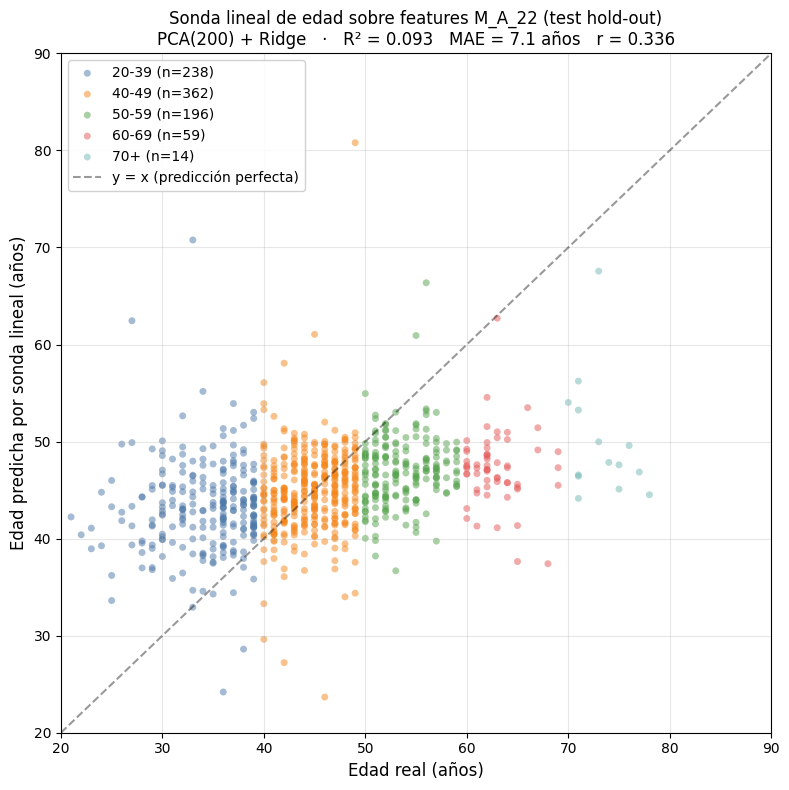


Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Plots\sonda_edad_scatter.png


In [4]:
# Edad real vs edad predicha
fig, ax = plt.subplots(figsize=(8, 8))

colors_rango = {'20-39':'#4c78a8', '40-49':'#f58518', '50-59':'#54a24b', '60-69':'#e45756', '70+':'#72b7b2'}
for lbl in _AGE_LABELS:
    mask = (age_bin_test == lbl)
    ax.scatter(y_test_age[mask], age_pred_test[mask], s=25, alpha=0.5, color=colors_rango[lbl], label=f'{lbl} (n={int(mask.sum())})', edgecolors='none')

lo, hi = 20, 90
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x (predicción perfecta)')

ax.set_xlabel('Edad real (años)', fontsize=12)
ax.set_ylabel('Edad predicha por sonda lineal (años)', fontsize=12)
ax.set_title(f'Sonda lineal de edad sobre features M_A_22 (test hold-out)\n'
             f'PCA(200) + Ridge   ·   R² = {r2:.3f}   MAE = {mae:.1f} años   r = {rho:.3f}',
             fontsize=12)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sonda_edad_scatter.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\nGuardado: {os.path.join(PLOTS_DIR, "sonda_edad_scatter.png")}')

## 4. Análisis D2 — Correlación entre el score del modelo final calibrado y la edad

**Pregunta:** ¿el score final que emite el modelo depende directamente de la edad del paciente?

**Método:** cargar los scores del modelo final (`M_A_22__xgb` agregado a estudio + calibración Platt) sobre el test hold-out. Calcular Pearson y Spearman entre score y edad, además de un boxplot del score por rango. Si la correlación es alta (|ρ| > 0,3), confirmaría dependencia directa.

El filtrado por edad ∈ [20, 90] se aplica **antes** de calcular las correlaciones, garantizando que Pearson y Spearman se calculan sobre el mismo subconjunto que la sonda lineal.

In [5]:
# Cargar scores del modelo final calibrado a nivel estudio
score_path = os.path.join(CALIB_DIR, 'M_A_22__xgb_agg_E__platt_test.npy')
assert os.path.exists(score_path), f'No encontrado: {score_path}'
score_test = np.load(score_path)
print(f'Scores calibrados: shape={score_test.shape}, rango=[{score_test.min():.4f}, {score_test.max():.4f}]')

# Alinear con edad del test
assert len(score_test) == is_test_E.sum(), 'Desalineación scores vs test'
age_E_test = age_E[is_test_E]
age_bin_E_test = age_bin_E[is_test_E]
y_E_test = y_E[is_test_E]

# Filtrar por edad válida (edad ∈ [20, 90], ya aplicado a age_E)
mask_valid = ~pd.isna(age_E_test)
score_v = score_test[mask_valid]
age_v = age_E_test[mask_valid]
age_bin_v = age_bin_E_test[mask_valid]
y_v = y_E_test[mask_valid]
print(f'Test tras filtrado edad: n={int(mask_valid.sum())} de {len(age_E_test)}, descartados={int((~mask_valid).sum())}')

# Correlaciones
rho_p, p_p = pearsonr(score_v, age_v)
rho_s, p_s = spearmanr(score_v, age_v)
print(f'\nCorrelación score calibrado <-> edad (test hold-out, n={len(score_v)})')
print(f'Pearson r = {rho_p:.4f} (p = {p_p:.2e})')
print(f'Spearman ρ = {rho_s:.4f} (p = {p_s:.2e})')

# Correlación por subgrupo positivo/negativo
print(f'\nCorrelación score <-> edad por clase real')
for label, name in [(0, 'Negativos (BI-RADS 1-3)'), (1, 'Positivos (BI-RADS 4-5)')]:
    m = (y_v == label)
    if m.sum() >= 2:
        r_c, p_c = pearsonr(score_v[m], age_v[m])
        print(f'{name:32s} n={int(m.sum()):4d} r={r_c:+.3f} (p={p_c:.2e})')

# Estadísticos del score por rango de edad
print(f'\nScore medio por rango de edad')
for lbl in _AGE_LABELS:
    m = (age_bin_v == lbl)
    n = int(m.sum())
    if n < 2:
        print(f'{lbl:6s} n={n:4d} score medio=NaN')
        continue
    print(f'{lbl:6s} n={n:4d} score medio={score_v[m].mean():.4f} ± {score_v[m].std():.4f} mediana={np.median(score_v[m]):.4f}')

Scores calibrados: shape=(1000,), rango=[0.0573, 0.3046]
Test tras filtrado edad: n=869 de 1000, descartados=131

Correlación score calibrado <-> edad (test hold-out, n=869)
Pearson r = 0.1633 (p = 1.30e-06)
Spearman ρ = 0.1970 (p = 4.72e-09)

Correlación score <-> edad por clase real
Negativos (BI-RADS 1-3)          n= 787 r=+0.061 (p=8.84e-02)
Positivos (BI-RADS 4-5)          n=  82 r=+0.258 (p=1.91e-02)

Score medio por rango de edad
20-39  n= 238 score medio=0.0804 ± 0.0253 mediana=0.0758
40-49  n= 362 score medio=0.0847 ± 0.0243 mediana=0.0807
50-59  n= 196 score medio=0.0870 ± 0.0218 mediana=0.0821
60-69  n=  59 score medio=0.0896 ± 0.0404 mediana=0.0805
70+    n=  14 score medio=0.1339 ± 0.0921 mediana=0.0763


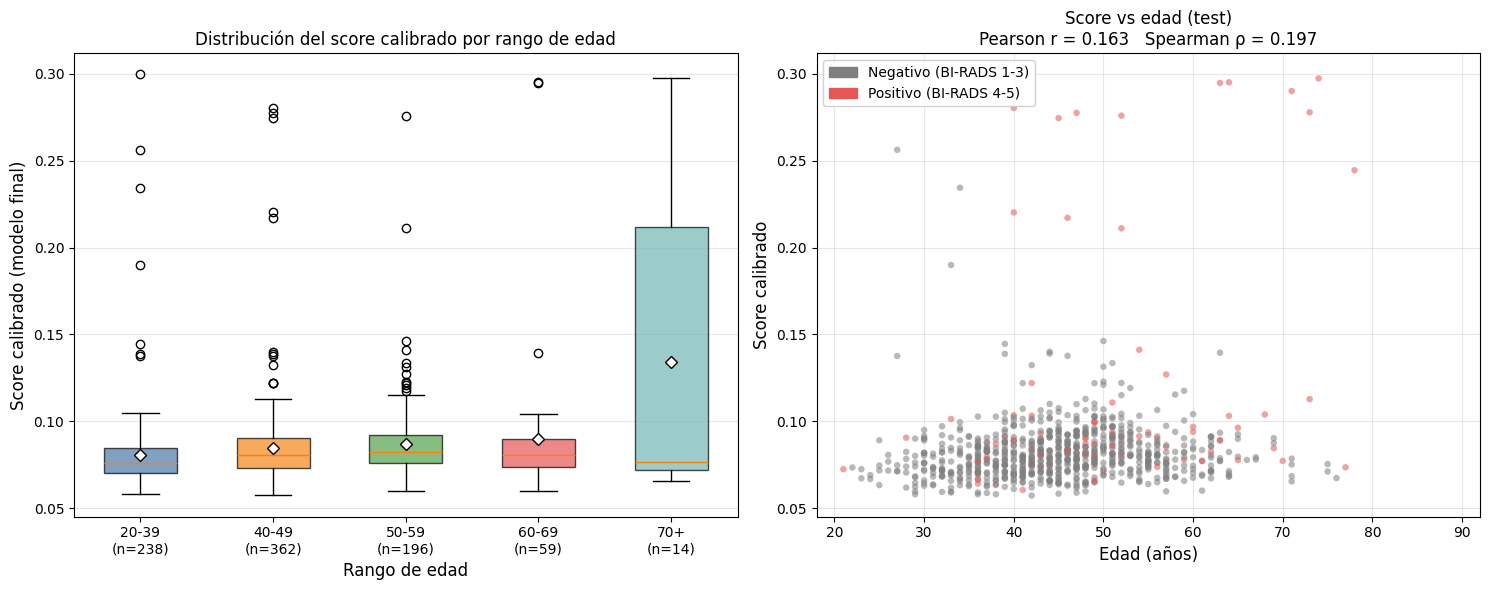

Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Plots\score_vs_edad.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
data_by_bin = [score_v[age_bin_v == lbl] for lbl in _AGE_LABELS]
positions = np.arange(len(_AGE_LABELS))
bp = ax.boxplot(data_by_bin, positions=positions, widths=0.55, patch_artist=True, showmeans=True, meanline=False, meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6))
for patch, lbl in zip(bp['boxes'], _AGE_LABELS):
    patch.set_facecolor(colors_rango[lbl])
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels([f'{lbl}\n(n={int((age_bin_v==lbl).sum())})' for lbl in _AGE_LABELS])
ax.set_ylabel('Score calibrado (modelo final)', fontsize=12)
ax.set_xlabel('Rango de edad', fontsize=12)
ax.set_title('Distribución del score calibrado por rango de edad', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
colors_y = ['#7f7f7f' if v==0 else '#e45756' for v in y_v]
ax.scatter(age_v, score_v, c=colors_y, s=22, alpha=0.55, edgecolors='none')
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Score calibrado', fontsize=12)
ax.set_title(f'Score vs edad (test)\nPearson r = {rho_p:.3f}   Spearman ρ = {rho_s:.3f}', fontsize=12)
ax.set_xlim(18, 92)
ax.grid(True, alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#7f7f7f', label='Negativo (BI-RADS 1-3)'), Patch(color='#e45756', label='Positivo (BI-RADS 4-5)')], loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'score_vs_edad.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: {os.path.join(PLOTS_DIR, "score_vs_edad.png")}')

## 5. Análisis D3 — Base rate + clasificador trivial "solo edad"

**Pregunta:** ¿un clasificador que solo utiliza la edad como entrada obtiene un AUC alto en 70+? Si sí, la mayor parte del AUC observado en el modelo final para ese rango puede atribuirse al efecto edad.

**Método:**
- Ajustar una **regresión logística con la edad como única covariable** sobre el training pool (aplicando el mismo filtro edad ∈ [20, 90]).
- Evaluarla sobre el test hold-out, calculando AUC global y AUC por rango con IC 95 % bootstrap.
- Comparar con el AUC del modelo final por rango: si en 70+ ambos AUCs son parecidos, el aporte del modelo por encima del prior de edad es pequeño en ese rango.

In [7]:
# Prevalencia positiva por rango sobre el test
print('Prevalencia positiva por rango de edad (test hold-out, edad rango [20, 90])')
print(f'{"Rango":<8}{"n":>6}{"pos":>6}{"neg":>6}{"prev %":>10}')
print('-' * 40)
for lbl in _AGE_LABELS:
    m = (age_bin_v == lbl)
    n = int(m.sum())
    n_pos = int(y_v[m].sum())
    n_neg = n - n_pos
    prev = 100 * y_v[m].mean() if n > 0 else 0
    print(f'{lbl:<8}{n:>6}{n_pos:>6}{n_neg:>6}{prev:>9.2f}')

# Ajustar LogReg solo con edad
train_valid = (~pd.isna(age_E)) & is_train_E
age_train = age_E[train_valid].reshape(-1, 1)
y_train = y_E[train_valid]
print(f'\nLogReg trivial: n_train = {len(y_train)}, prevalencia = {100*y_train.mean():.2f} %')

clf_edad = LogisticRegression(C=1e6, max_iter=1000, random_state=SEED)
clf_edad.fit(age_train, y_train)

age_test_arr = age_v.reshape(-1, 1)
p_edad_test = clf_edad.predict_proba(age_test_arr)[:, 1]

print(f'\nClasificador trivial "solo edad" (LogReg)')
print(f'Coeficiente edad: {float(clf_edad.coef_[0,0]):+.4f}, Intercepto: {float(clf_edad.intercept_[0]):+.4f}')
print(f'AUC global test: {roc_auc_score(y_v, p_edad_test):.4f}')
print(f'(Coeficiente positivo -> a más edad, mayor probabilidad predicha de positivo, coherente clínicamente)')

# Comparación por rango: modelo final vs "solo edad"
rows = []
for lbl in _AGE_LABELS:
    m = (age_bin_v == lbl)
    n = int(m.sum())
    n_pos = int(y_v[m].sum())
    if n_pos < 2 or (n - n_pos) < 2:
        rows.append({'rango': lbl, 'n': n, 'n_pos': n_pos, 'auc_modelo': np.nan, 'auc_solo_edad': np.nan})
        continue
    auc_modelo, lo_m, hi_m = bootstrap_metric_ci(y_v[m], score_v[m], roc_auc_score, n_boot=1000)
    auc_edad,   lo_e, hi_e = bootstrap_metric_ci(y_v[m], p_edad_test[m], roc_auc_score, n_boot=1000)
    rows.append({'rango': lbl, 'n': n, 'n_pos': n_pos, 'auc_modelo': auc_modelo, 'auc_modelo_lo': lo_m, 'auc_modelo_hi': hi_m, 'auc_solo_edad': auc_edad, 'auc_solo_edad_lo': lo_e, 'auc_solo_edad_hi': hi_e})

df_comp = pd.DataFrame(rows)
print(f'\nAUC por rango: modelo final vs clasificador "solo edad"')
print(f'{"Rango":<8}{"n":>6}{"pos":>6}{"AUC modelo":>20}{"AUC solo edad":>22}      Δ')
print('-' * 78)
for _, r in df_comp.iterrows():
    if pd.isna(r['auc_modelo']):
        print(f'{r["rango"]:<8}{r["n"]:>6}{r["n_pos"]:>6}{"NaN (n insuf.)":>20}{"NaN":>22}')
    else:
        delta = r['auc_modelo'] - r['auc_solo_edad']
        print(f'{r["rango"]:<8}{r["n"]:>6}{r["n_pos"]:>6}'
              f'  {r["auc_modelo"]:.3f} [{r["auc_modelo_lo"]:.3f}, {r["auc_modelo_hi"]:.3f}]'
              f'  {r["auc_solo_edad"]:.3f} [{r["auc_solo_edad_lo"]:.3f}, {r["auc_solo_edad_hi"]:.3f}]'
              f'  {delta:+.3f}')

df_comp.to_csv(os.path.join(PRED_DIR, 'analisis_sonda_edad.csv'), index=False)
print(f'\nGuardado: {os.path.join(PRED_DIR, "analisis_sonda_edad.csv")}')

Prevalencia positiva por rango de edad (test hold-out, edad rango [20, 90])
Rango        n   pos   neg    prev %
----------------------------------------
20-39      238    14   224     5.88
40-49      362    31   331     8.56
50-59      196    18   178     9.18
60-69       59    12    47    20.34
70+         14     7     7    50.00

LogReg trivial: n_train = 3433, prevalencia = 9.23 %

Clasificador trivial "solo edad" (LogReg)
Coeficiente edad: +0.0353, Intercepto: -3.9291
AUC global test: 0.6312
(Coeficiente positivo -> a más edad, mayor probabilidad predicha de positivo, coherente clínicamente)

AUC por rango: modelo final vs clasificador "solo edad"
Rango        n   pos          AUC modelo         AUC solo edad      Δ
------------------------------------------------------------------------------
20-39      238    14  0.592 [0.413, 0.762]  0.606 [0.443, 0.751]  -0.014
40-49      362    31  0.655 [0.549, 0.753]  0.538 [0.411, 0.661]  +0.117
50-59      196    18  0.645 [0.507, 0.781]  

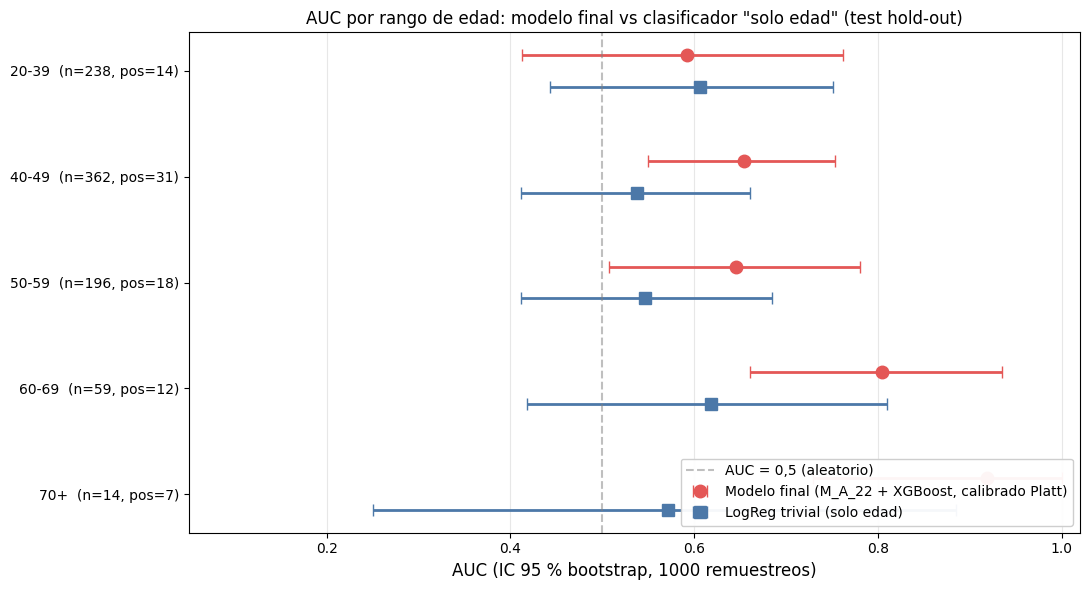

Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Plots\auc_por_edad_modelo_vs_soloedad.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(df_comp))

for i, (_, r) in enumerate(df_comp.iterrows()):
    if pd.isna(r['auc_modelo']):
        ax.text(0.5, i, f'n insuficiente (pos={r["n_pos"]})', va='center', ha='center', fontsize=9, color='gray')
        continue
    ax.errorbar(r['auc_modelo'], i - 0.15,
                xerr=[[r['auc_modelo']-r['auc_modelo_lo']], [r['auc_modelo_hi']-r['auc_modelo']]],
                fmt='o', color='#e45756', capsize=4, markersize=9, linewidth=2,
                label='Modelo final (M_A_22 + XGBoost, calibrado Platt)' if i==0 else None)
    ax.errorbar(r['auc_solo_edad'], i + 0.15,
                xerr=[[r['auc_solo_edad']-r['auc_solo_edad_lo']], [r['auc_solo_edad_hi']-r['auc_solo_edad']]],
                fmt='s', color='#4c78a8', capsize=4, markersize=9, linewidth=2,
                label='LogReg trivial (solo edad)' if i==0 else None)

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='AUC = 0,5 (aleatorio)')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{r["rango"]}  (n={r["n"]}, pos={r["n_pos"]})' for _, r in df_comp.iterrows()])
ax.set_xlabel('AUC (IC 95 % bootstrap, 1000 remuestreos)', fontsize=12)
ax.set_title('AUC por rango de edad: modelo final vs clasificador "solo edad" (test hold-out)', fontsize=12)
ax.set_xlim(0.05, 1.02)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'auc_por_edad_modelo_vs_soloedad.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: {os.path.join(PLOTS_DIR, "auc_por_edad_modelo_vs_soloedad.png")}')

## 6. Interpretación integrada

Los tres análisis anteriores permiten responder cuantitativamente a la pregunta planteada en la motivación. La celda siguiente sintetiza los resultados y produce un veredicto matizado con umbrales conservadores.

In [9]:
print('RESUMEN DEL ANÁLISIS - ¿Predice el modelo la edad implícitamente?')
print('-' * 78)
print()
print(f'D1 - Sonda lineal PCA(200) + Ridge sobre M_A_22 (test hold-out):')
print(f'R² = {r2:.3f}, MAE = {mae:.1f} años, Pearson r = {rho:.3f}')
if r2 > 0.3:
    dict_d1 = 'Las features codifican la edad de forma CLARA.'
elif r2 > 0.1:
    dict_d1 = 'Las features codifican la edad de forma MODERADA.'
else:
    dict_d1 = 'Las features codifican la edad DÉBILMENTE.'
print(f'-> {dict_d1}')
print()

print(f'D2 - Correlación score calibrado <-> edad sobre test:')
print(f'Pearson r = {rho_p:.3f}, Spearman ρ = {rho_s:.3f}')
if abs(rho_p) > 0.3:
    dict_d2 = 'DEPENDENCIA DIRECTA del score con la edad.'
elif abs(rho_p) > 0.15:
    dict_d2 = 'Dependencia MODERADA del score con la edad.'
else:
    dict_d2 = 'Dependencia DÉBIL del score con la edad.'
print(f'-> {dict_d2}')
print()

print(f'D3 - Comparación modelo final vs clasificador "solo edad" por rango:')
auc_g_modelo = roc_auc_score(y_v, score_v)
auc_g_solo_edad = roc_auc_score(y_v, p_edad_test)
print(f'AUC global modelo final: {auc_g_modelo:.3f}')
print(f'AUC global solo edad: {auc_g_solo_edad:.3f}')
print(f'Δ global: {auc_g_modelo - auc_g_solo_edad:+.3f}')
print()

# Rango 70+ específico
r70 = df_comp[df_comp.rango == '70+'].iloc[0]
if not pd.isna(r70['auc_modelo']):
    delta_70 = r70['auc_modelo'] - r70['auc_solo_edad']
    print(f'Rango 70+ (foco de la hipótesis):')
    print(f'AUC modelo: {r70["auc_modelo"]:.3f} [{r70["auc_modelo_lo"]:.3f}, {r70["auc_modelo_hi"]:.3f}]')
    print(f'AUC solo edad: {r70["auc_solo_edad"]:.3f} [{r70["auc_solo_edad_lo"]:.3f}, {r70["auc_solo_edad_hi"]:.3f}]')
    print(f'Δ (modelo - solo edad): {delta_70:+.3f}')
    if delta_70 < 0.05:
        print(f'-> El modelo NO APORTA valor significativo sobre "solo edad" en 70+.')
    elif delta_70 < 0.15:
        print(f'-> El modelo aporta VALOR MODERADO sobre "solo edad" en 70+.')
    else:
        print(f'-> El modelo APORTA VALOR CLARO sobre "solo edad" en 70+.')
    print()
    print(f'Nota metodológica: con n=14 estudios y pos=7 en 70+, los IC bootstrap son muy anchos.')
    print(f'Cualquier interpretación en este rango es tentativa y debe reportarse con esta reserva.')

# Guardar resumen
resumen = {
    'n_test_edad_valida': int(mask_valid.sum()),
    'n_test_descartados': int((~mask_valid).sum()),
    'r2_sonda_edad': r2,
    'mae_sonda_edad_anos': mae,
    'pearson_sonda_edad': rho,
    'pearson_score_edad': rho_p,
    'spearman_score_edad': rho_s,
    'auc_global_modelo': auc_g_modelo,
    'auc_global_solo_edad': auc_g_solo_edad,
    'delta_global': auc_g_modelo - auc_g_solo_edad,
    'coef_logreg_edad': float(clf_edad.coef_[0,0]),
    'intercepto_logreg_edad': float(clf_edad.intercept_[0]),
}
if not pd.isna(r70['auc_modelo']):
    resumen.update({
        'auc_70plus_modelo': r70['auc_modelo'],
        'auc_70plus_solo_edad': r70['auc_solo_edad'],
        'delta_70plus': delta_70,
    })
pd.DataFrame([resumen]).to_csv(os.path.join(PRED_DIR, 'resumen_analisis_edad.csv'), index=False)
print(f'\nGuardado: resumen_analisis_edad.csv')

RESUMEN DEL ANÁLISIS - ¿Predice el modelo la edad implícitamente?
------------------------------------------------------------------------------

D1 - Sonda lineal PCA(200) + Ridge sobre M_A_22 (test hold-out):
R² = 0.093, MAE = 7.1 años, Pearson r = 0.336
-> Las features codifican la edad DÉBILMENTE.

D2 - Correlación score calibrado <-> edad sobre test:
Pearson r = 0.163, Spearman ρ = 0.197
-> Dependencia MODERADA del score con la edad.

D3 - Comparación modelo final vs clasificador "solo edad" por rango:
AUC global modelo final: 0.682
AUC global solo edad: 0.631
Δ global: +0.051

Rango 70+ (foco de la hipótesis):
AUC modelo: 0.918 [0.729, 1.000]
AUC solo edad: 0.571 [0.250, 0.886]
Δ (modelo - solo edad): +0.347
-> El modelo APORTA VALOR CLARO sobre "solo edad" en 70+.

Nota metodológica: con n=14 estudios y pos=7 en 70+, los IC bootstrap son muy anchos.
Cualquier interpretación en este rango es tentativa y debe reportarse con esta reserva.

Guardado: resumen_analisis_edad.csv
